In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from simlm.analysis import (
    load_and_process_results,
    plot_metric_distribution,
    plot_success_rate,
    plot_metric_by_difficulty,
    plot_iterations_histogram,
    print_summary_stats,
    plot_simlm_cot_error_ratio,
    plot_error_ratio_by_ground,
    summarize_average_error_by_ground,
    summarize_improvement_by_ground,
    summarize_relative_improvement,
    plot_error_vs_ground_difficulty,
    summarize_failure_rate,
    plot_iterations_vs_error,
    plot_histogram_error_distribution,
    perform_statistical_tests
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Configurations
RESULTS_DIR = Path("results") 
RESULT_FILE = RESULTS_DIR / "combined_results_v1.jsonl" 
sns.set_theme(style="whitegrid")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 100 # Adjust plot resolution if needed

In [2]:
results_df = load_and_process_results(RESULT_FILE)

Loading results from: results/combined_results_v1.jsonl
Processed 3514 results after cleaning.


In [3]:
results_df.head()

,Timestamp,Time Taken (s),Iterations Run,Num Few Shot,Final Height (m),Final Velocity (m/s),Actual Distance Bounce 3 (m),Bounce Locations (m),Strategy,Target Distance (m),...,LLM Service,LLM Model Name,LLM Temperature,Ground Type,Ground Difficulty,Target Bounce Number,Tolerance (m),Error,Success,Experiment Condition
0,2025-04-27 18:18:59,103.500035,1,0,13.2,47.8,207.206463,"[78.29639999999972, 271.86651519416915, 207.20...",Baseline CoT,50.0,...,Ollama,llama2:7b,0.5,Flat,0.9,3,1,157.206463,False,Flat Ground (Exp A)
1,2025-04-27 18:19:02,3.692219,1,1,12.6,47.9,338.653000,"[76.63999999999817, 214.54409999999385, 338.65...",Baseline CoT,50.0,...,Ollama,llama2:7b,0.5,Flat,0.9,3,1,288.653000,False,Flat Ground (Exp A)
2,2025-04-27 18:19:06,3.571044,1,2,14.9,50.7,389.933700,"[88.21800000000222, 247.01040000002158, 389.93...",Baseline CoT,50.0,...,Ollama,llama2:7b,0.5,Flat,0.9,3,1,339.933700,False,Flat Ground (Exp A)
3,2025-04-27 18:19:09,3.649511,1,0,11.2,47.8,NaN,"[72.08240000000035, 305.61911138698343]",Baseline CoT,50.0,...,Ollama,llama2:7b,0.5,Flat,0.9,3,1,NaN,False,Flat Ground (Exp A)
4,2025-04-27 18:19:14,4.550663,1,1,14.2,47.8,358.834600,"[81.21219999999943, 227.3367999999847, 358.834...",Baseline CoT,50.0,...,Ollama,llama2:7b,0.5,Flat,0.9,3,1,308.834600,False,Flat Ground (Exp A)


In [4]:
# Summary stats
print("\nOverview")
results_df.info()

print("\nCounts")
print("Strategies:\n", results_df['Strategy'].value_counts())
print("\nExperiment Conditions:\n", results_df['Experiment Condition'].value_counts())
print("\nLLM Models:\n", results_df['LLM Model Name'].value_counts())

print_summary_stats(results_df)


Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3514 entries, 0 to 3513
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Timestamp                     3514 non-null   datetime64[ns]
 1   Time Taken (s)                3061 non-null   float64       
 2   Iterations Run                3514 non-null   int64         
 3   Num Few Shot                  3514 non-null   int64         
 4   Final Height (m)              3061 non-null   float64       
 5   Final Velocity (m/s)          3061 non-null   float64       
 6   Actual Distance Bounce 3 (m)  2849 non-null   float64       
 7   Bounce Locations (m)          3061 non-null   object        
 8   Strategy                      3514 non-null   object        
 9   Target Distance (m)           3514 non-null   float64       
 10  Max Iterations Allowed        3514 non-null   int64         
 11  LLM Service         

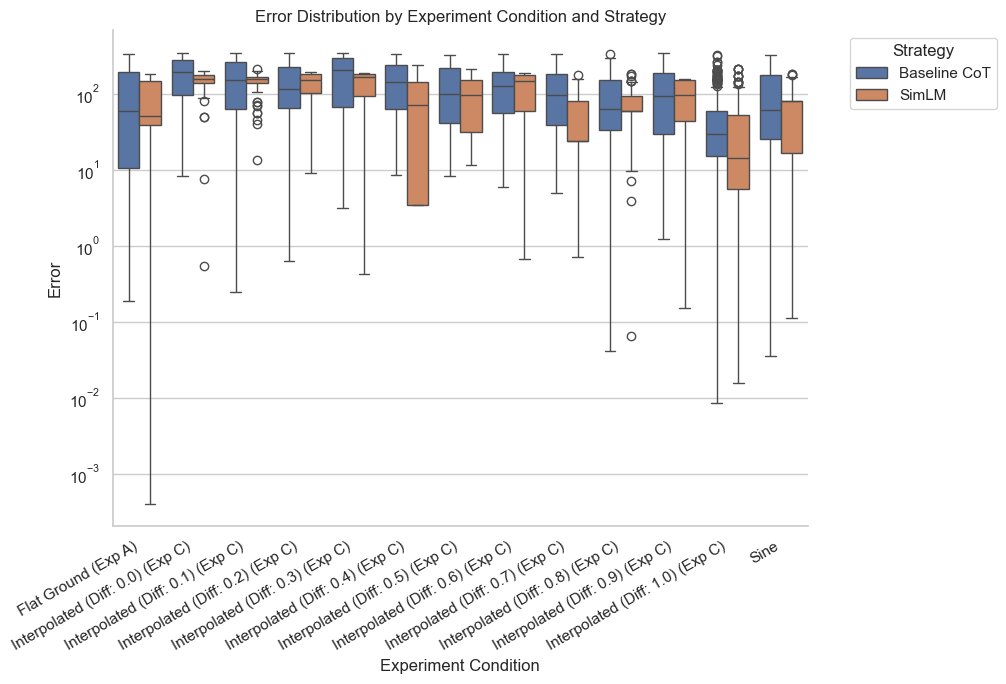

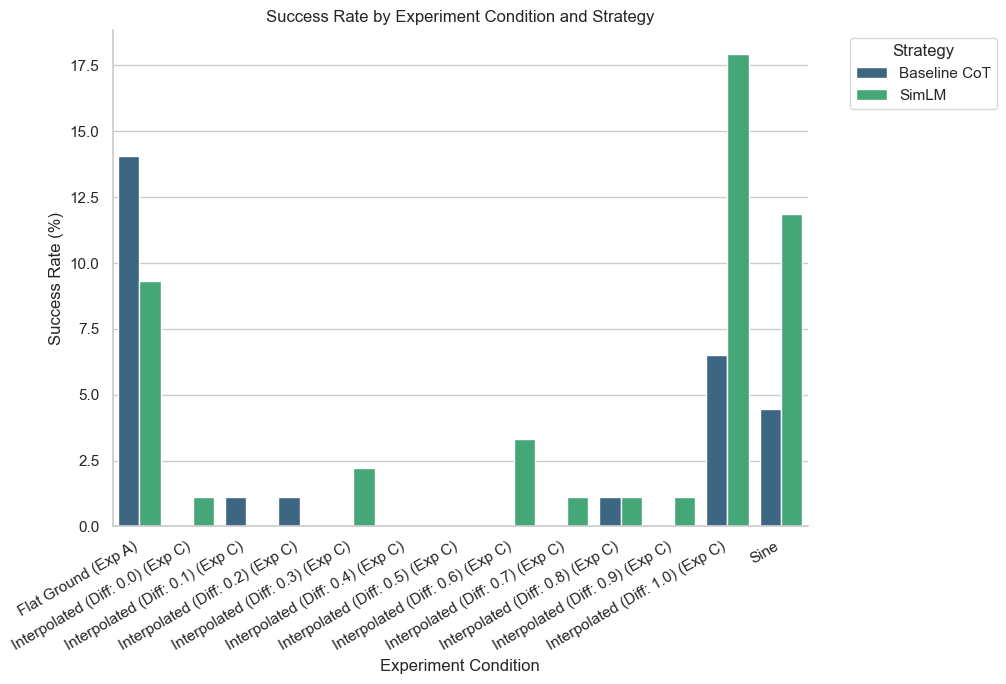

In [5]:
##### Strategy Comparison #####

# Error Distribution
plot_metric_distribution(
    results_df,
    metric_col='Error',
    group_col='Experiment Condition', 
    hue_col='Strategy',
    title='Error Distribution by Experiment Condition and Strategy',
    yscale='log' 
)

# Success Rate
plot_success_rate(
    results_df,
    group_col='Experiment Condition',
    hue_col='Strategy',
    title='Success Rate by Experiment Condition and Strategy'
)

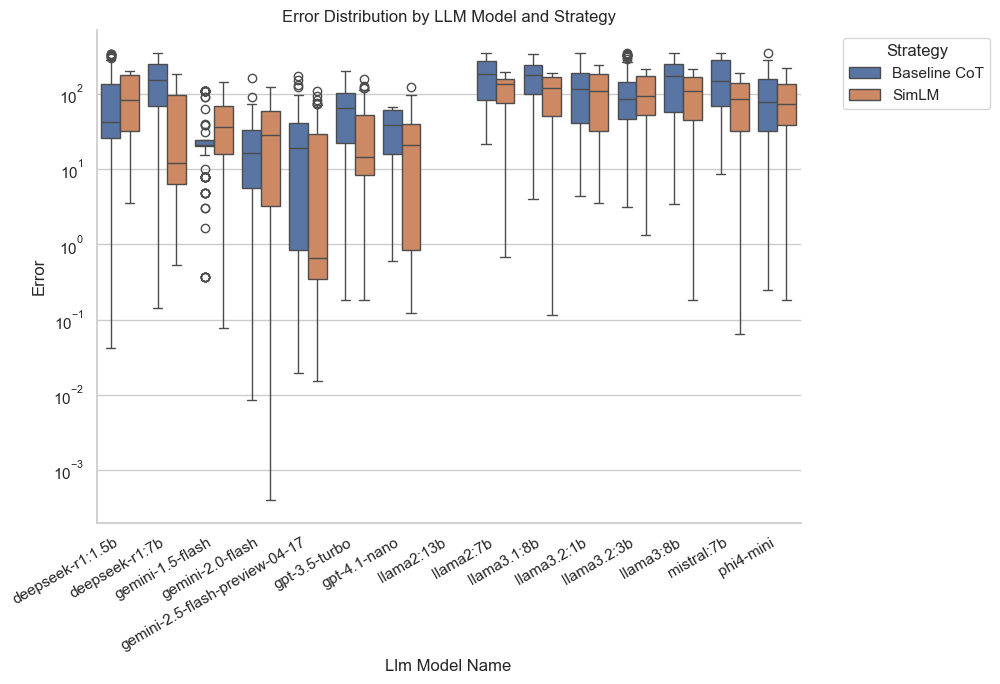

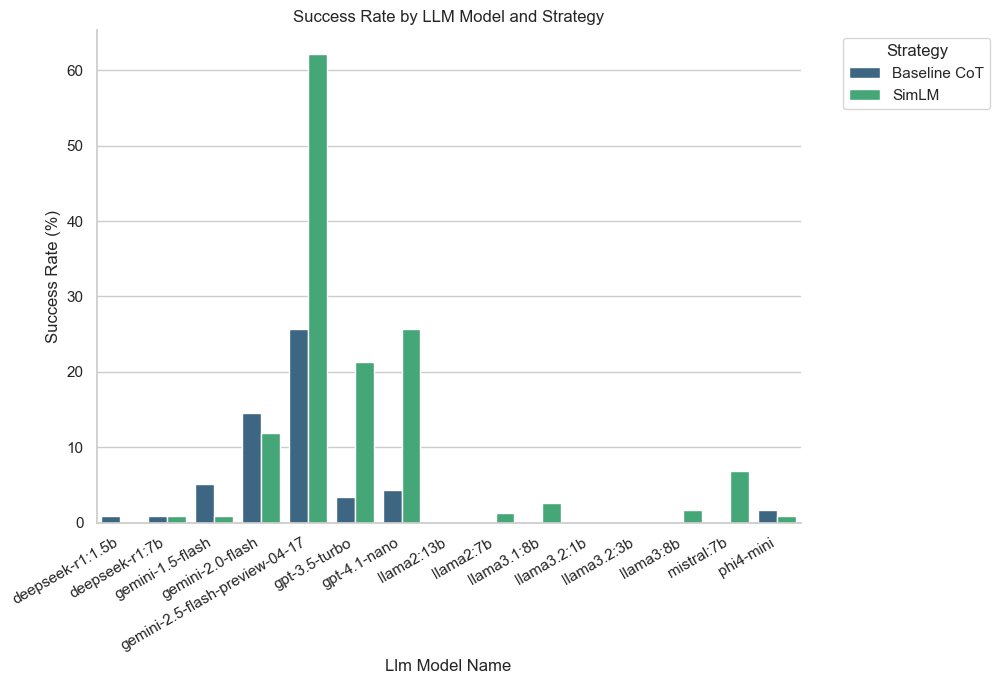

In [6]:
##### LLM Comparison #####

# Error Distribution
plot_metric_distribution(
    results_df,
    metric_col='Error',
    group_col='LLM Model Name',
    hue_col='Strategy',
    title='Error Distribution by LLM Model and Strategy',
    yscale='log'
)

# Success Rate
plot_success_rate(
    results_df,
    group_col='LLM Model Name',
    hue_col='Strategy',
    title='Success Rate by LLM Model and Strategy'
)

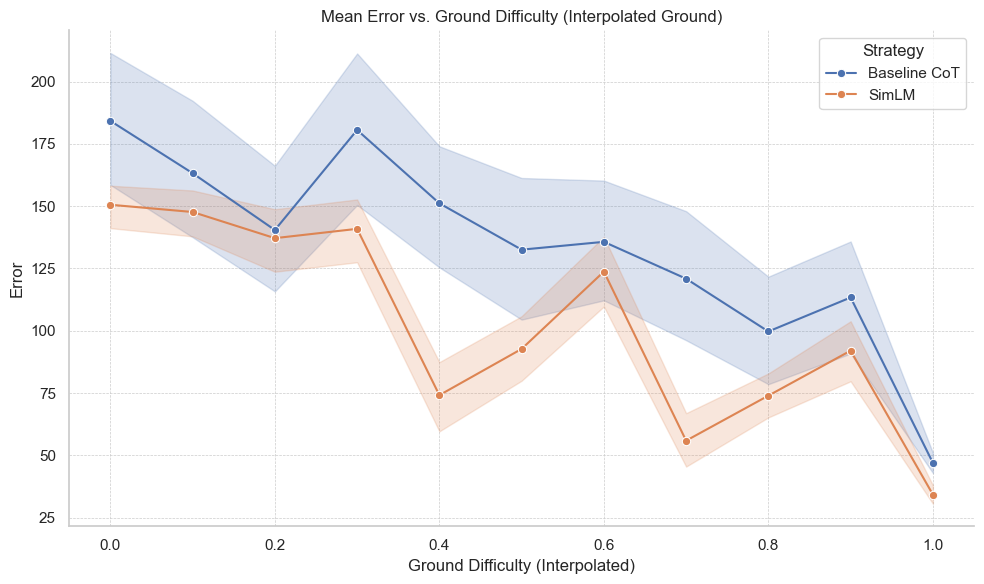

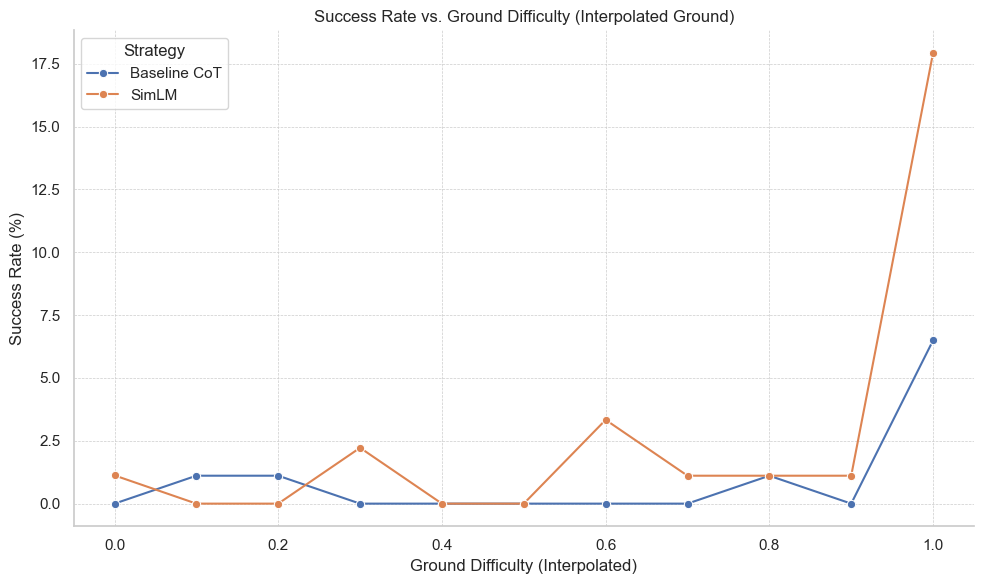

In [7]:
##### Experiment C #####

# Error vs. Difficulty
plot_metric_by_difficulty(
        results_df,
        metric_col='Error',
        title='Mean Error vs. Ground Difficulty (Interpolated Ground)'
)

# Success Rate vs. Difficulty

exp_c_df_succ = results_df[results_df['Ground Type'] == 'Interpolated'].copy()
success_by_diff = exp_c_df_succ.groupby(['Ground Difficulty', 'Strategy'], observed=False)['Success'].mean().reset_index()
success_by_diff['Success Rate (%)'] = success_by_diff['Success'] * 100

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=success_by_diff,
    x='Ground Difficulty',
    y='Success Rate (%)',
    hue='Strategy',
    marker='o'
)
plt.title('Success Rate vs. Ground Difficulty (Interpolated Ground)')
plt.xlabel("Ground Difficulty (Interpolated)")
plt.ylabel('Success Rate (%)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Strategy')
plt.tight_layout()
plt.show()

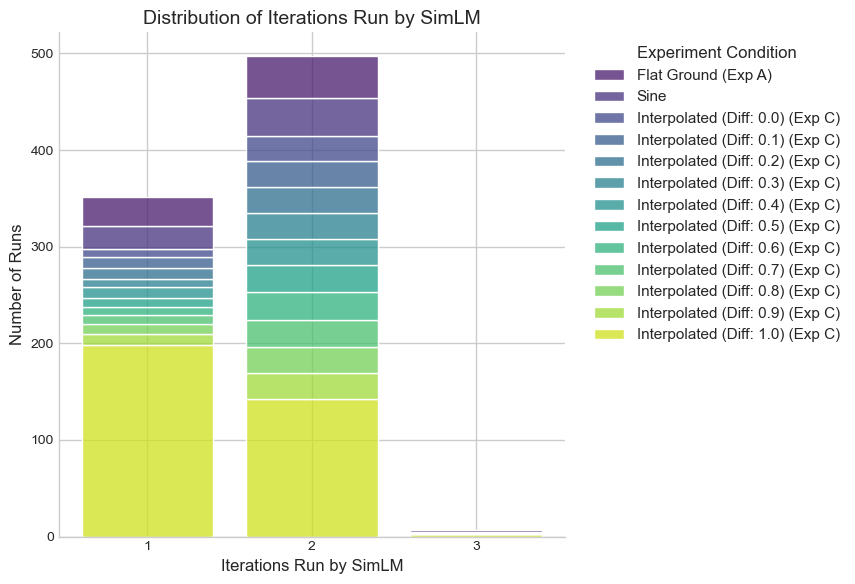

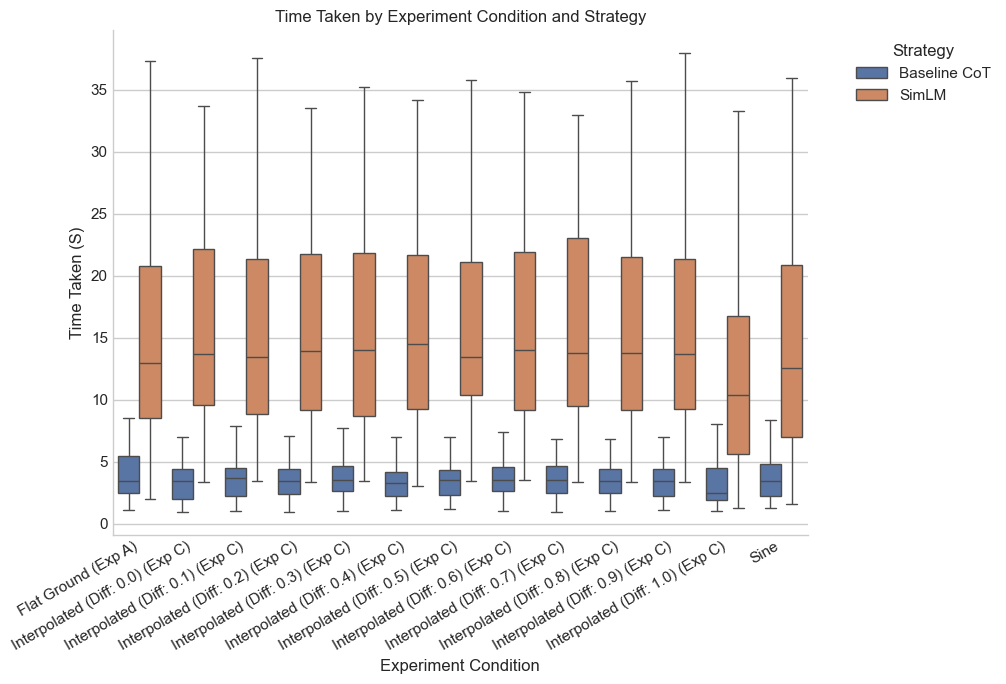

In [8]:
##### General analysis #####

# Iterations 
plot_iterations_histogram(
    results_df,
    title='Distribution of Iterations Run by SimLM'
)

# Time Taken Comparison
plot_metric_distribution(
    results_df,
    metric_col='Time Taken (s)',
    group_col='Experiment Condition',
    hue_col='Strategy',
    title='Time Taken by Experiment Condition and Strategy',
    showfliers=False 
)

Strategy                        Baseline CoT      SimLM
LLM Model Name                                         
deepseek-r1:1.5b                   92.899111  98.563483
deepseek-r1:7b                    159.895414  64.728833
gemini-1.5-flash                   33.744675  46.667400
gemini-2.0-flash                   22.158090  36.826615
gemini-2.5-flash-preview-04-17     27.538549  16.611150


/Users/alejandro/Developer/gatech/dl/CS7643-DL-Final/simlm/analysis.py:474: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


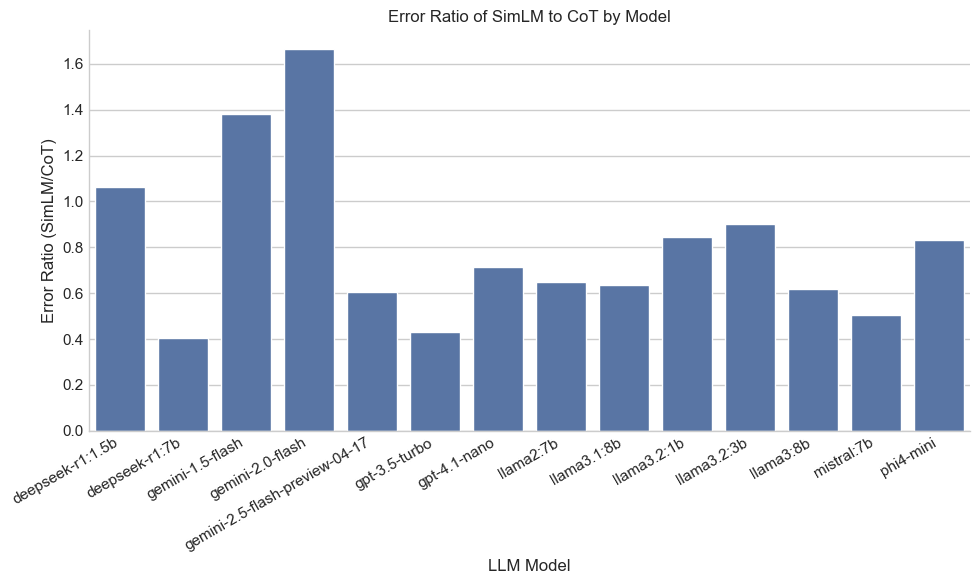

In [9]:
plot_simlm_cot_error_ratio(results_df)

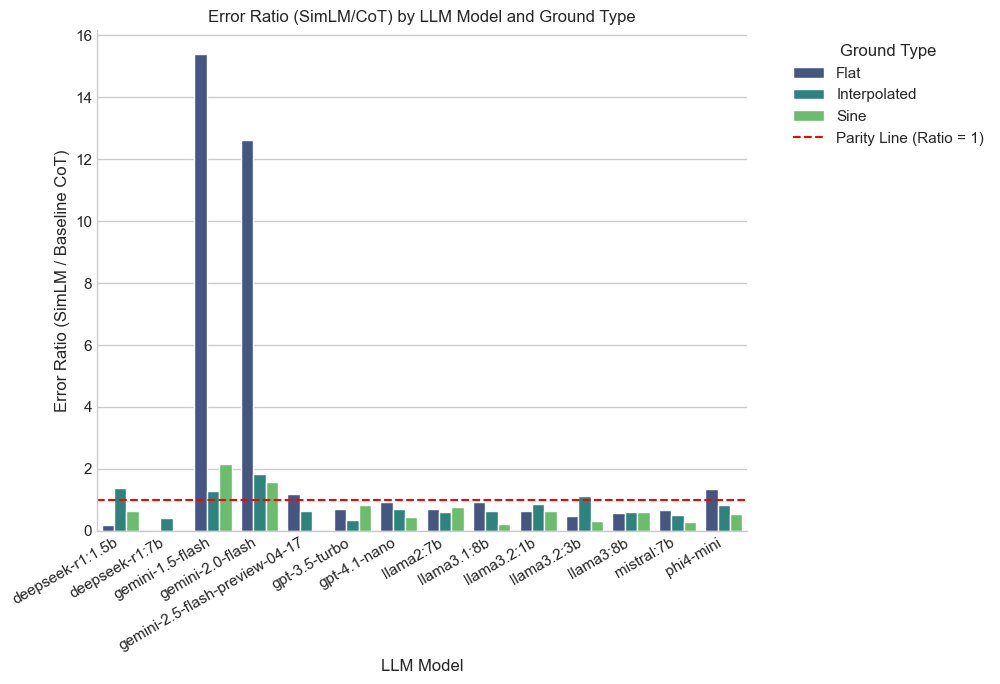

In [10]:
plot_error_ratio_by_ground(results_df)

In [11]:
summarize_average_error_by_ground(results_df)


--- Average Error by LLM Model and Ground Type ---


Ground Type,Flat,Interpolated,Sine
LLM Model Name,,,
deepseek-r1:1.5b,159.67,89.24,104.07
deepseek-r1:7b,198.79,154.39,192.95
gemini-1.5-flash,13.84,41.35,34.32
gemini-2.0-flash,3.07,32.28,29.53
gemini-2.5-flash-preview-04-17,13.18,22.26,56.66
gpt-3.5-turbo,85.37,45.05,53.61
gpt-4.1-nano,25.19,34.48,15.46
llama2:7b,171.42,123.97,111.24
llama3.1:8b,152.85,137.39,90.95


In [12]:
summarize_improvement_by_ground(results_df)


--- Improvement (Baseline CoT - SimLM) by LLM Model and Ground Type ---


Ground Type,Flat,Interpolated,Sine
LLM Model Name,,,
deepseek-r1:1.5b,214.60,-29.56,44.89
gemini-1.5-flash,-29.47,-10.32,-27.47
gemini-2.0-flash,-4.36,-20.16,-12.78
gpt-3.5-turbo,27.94,42.63,9.59
gpt-4.1-nano,1.33,11.54,12.24
llama2:7b,65.88,65.63,30.81
llama3.1:8b,8.97,59.47,119.36
llama3.2:1b,26.83,18.51,48.53
llama3.2:3b,74.62,-11.18,198.35


In [13]:
summarize_relative_improvement(results_df)


--- Relative Improvement (%) by LLM Model and Ground Type ---


Ground Type,Flat,Interpolated,Sine
LLM Model Name,,,
deepseek-r1:1.5b,80.4,-39.5,35.5
gemini-1.5-flash,-1438.8,-27.4,-115.6
gemini-2.0-flash,-1162.8,-83.4,-58.8
gpt-3.5-turbo,28.1,64.2,16.4
gpt-4.1-nano,5.1,28.6,55.8
llama2:7b,29.5,37.5,23.1
llama3.1:8b,5.7,35.1,77.4
llama3.2:1b,34.3,13.7,37.3
llama3.2:3b,52.3,-11.6,67.8


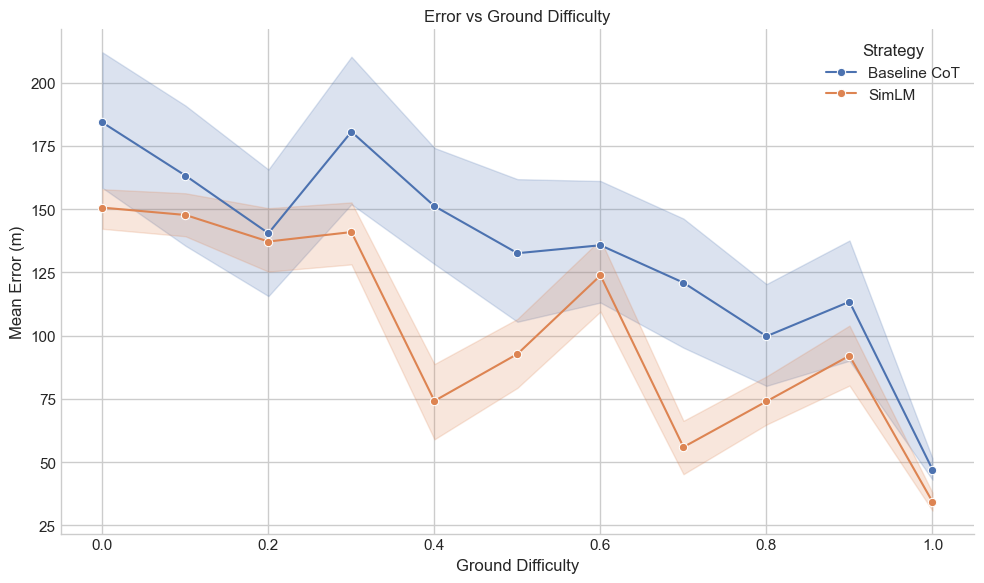

In [14]:
plot_error_vs_ground_difficulty(results_df)

In [15]:
summarize_failure_rate(results_df)


--- Failure Rate (%) by LLM Model and Strategy ---


LLM Model Name                  Strategy    
deepseek-r1:1.5b                Baseline CoT    81.2
                                SimLM           78.6
deepseek-r1:7b                  Baseline CoT    68.4
                                SimLM            0.9
gemini-1.5-flash                Baseline CoT    71.8
                                SimLM           35.0
gemini-2.0-flash                Baseline CoT    38.5
                                SimLM           33.6
gemini-2.5-flash-preview-04-17  Baseline CoT    45.3
                                SimLM           26.8
gpt-3.5-turbo                   Baseline CoT    78.6
                                SimLM           30.8
gpt-4.1-nano                    Baseline CoT    68.4
                                SimLM           50.4
llama2:13b                      Baseline CoT     0.0
llama2:7b                       Baseline CoT    59.8
                                SimLM           87.7
llama3.1:8b                     Baseline CoT    79.5
 

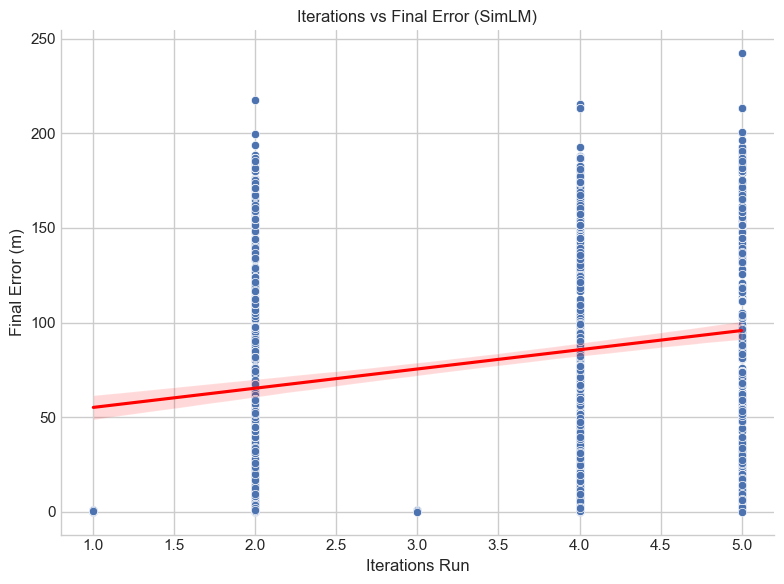

In [16]:
plot_iterations_vs_error(results_df)

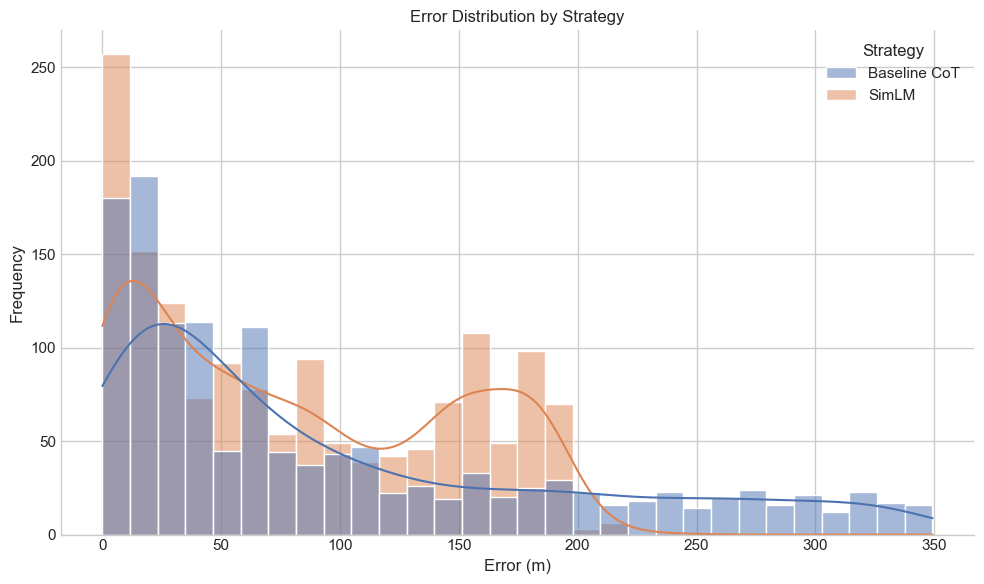

In [17]:
plot_histogram_error_distribution(results_df)

In [18]:
perform_statistical_tests(results_df)


--- Statistical Significance Tests (Baseline CoT vs SimLM for Error) ---

Testing for Group: Flat Ground (Exp A)
  Baseline CoT Mean Error: 102.574 (N=100)
  SimLM Mean Error: 81.927 (N=126)
  T-statistic: 1.735, P-value: 0.0848
  Difference significant at alpha=0.05? No (p=0.0848)

Testing for Group: Sine
  Baseline CoT Mean Error: 110.516 (N=104)
  SimLM Mean Error: 63.307 (N=118)
  T-statistic: 4.163, P-value: 5.52e-05
  Difference significant at alpha=0.05? Yes (p=5.52e-05)

Testing for Group: Interpolated (Diff: 0.0) (Exp C)
  Baseline CoT Mean Error: 184.210 (N=60)
  SimLM Mean Error: 150.564 (N=80)
  T-statistic: 2.355, P-value: 0.0213
  Difference significant at alpha=0.05? Yes (p=0.0213)

Testing for Group: Interpolated (Diff: 0.1) (Exp C)
  Baseline CoT Mean Error: 163.217 (N=59)
  SimLM Mean Error: 147.656 (N=77)
  T-statistic: 1.039, P-value: 0.303
  Difference significant at alpha=0.05? No (p=0.303)

Testing for Group: Interpolated (Diff: 0.2) (Exp C)
  Baseline CoT Mean 

,Group,Stat,P-Value,Significant,N1,N2
0,Flat Ground (Exp A),1.734878,8.477556e-02,No (p=0.0848),100,126
1,Sine,4.162695,5.523297e-05,Yes (p=5.52e-05),104,118
2,Interpolated (Diff: 0.0) (Exp C),2.355367,2.129659e-02,Yes (p=0.0213),60,80
3,Interpolated (Diff: 0.1) (Exp C),1.038650,3.025747e-01,No (p=0.303),59,77
4,Interpolated (Diff: 0.2) (Exp C),0.227429,8.206207e-01,No (p=0.821),61,79
5,Interpolated (Diff: 0.3) (Exp C),2.388029,1.932294e-02,Yes (p=0.0193),59,81
6,Interpolated (Diff: 0.4) (Exp C),5.349242,5.185020e-07,Yes (p=5.19e-07),63,78
7,Interpolated (Diff: 0.5) (Exp C),2.441531,1.733695e-02,Yes (p=0.0173),47,79
8,Interpolated (Diff: 0.6) (Exp C),0.834620,4.060752e-01,No (p=0.406),57,81
9,Interpolated (Diff: 0.7) (Exp C),4.583022,2.082902e-05,Yes (p=2.08e-05),50,81



Summary by Condition & Strategy:
                Experiment Condition      Strategy  Num Few Shot  Mean Error  Median Error  Std Dev Error  Valid Run Count  Success Rate
0                Flat Ground (Exp A)  Baseline CoT             0   92.194487     39.081106      97.717678               33      0.060606
1                Flat Ground (Exp A)  Baseline CoT             1  105.308793     90.289176     103.538887               33      0.272727
2                Flat Ground (Exp A)  Baseline CoT             2  109.992924     65.946000     115.417925               34      0.235294
3                Flat Ground (Exp A)         SimLM             0   81.240295     51.424656      61.905144               38      0.105263
4                Flat Ground (Exp A)         SimLM             1   78.807082     51.424656      61.779181               45      0.133333
5                Flat Ground (Exp A)         SimLM             2   85.797645     51.424656      65.410977               43      0.093023
6   Int

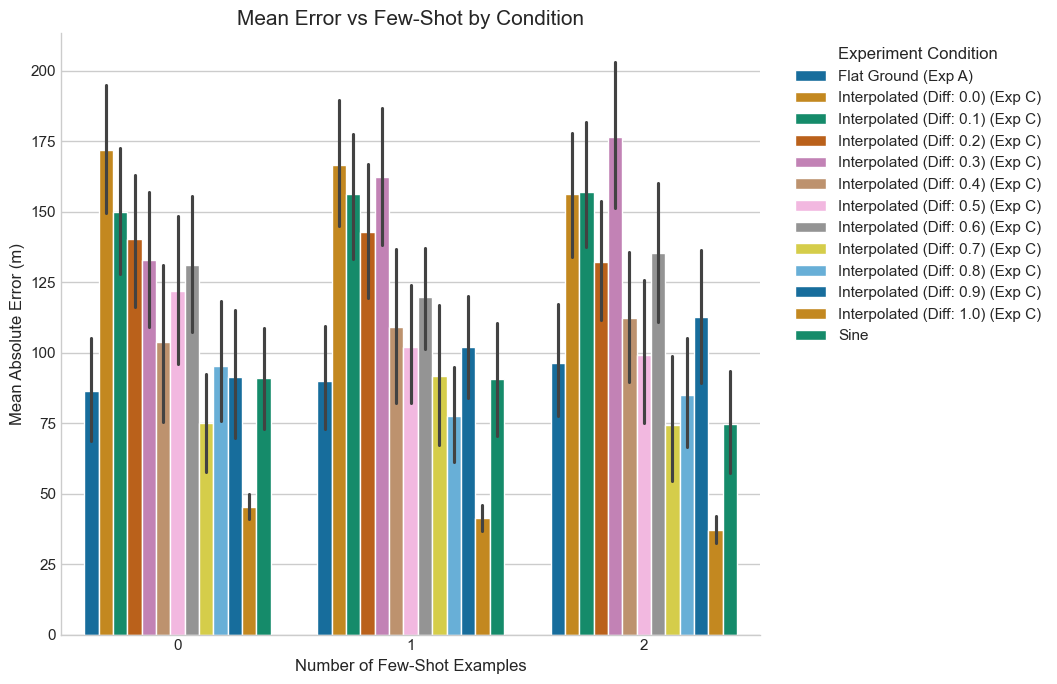

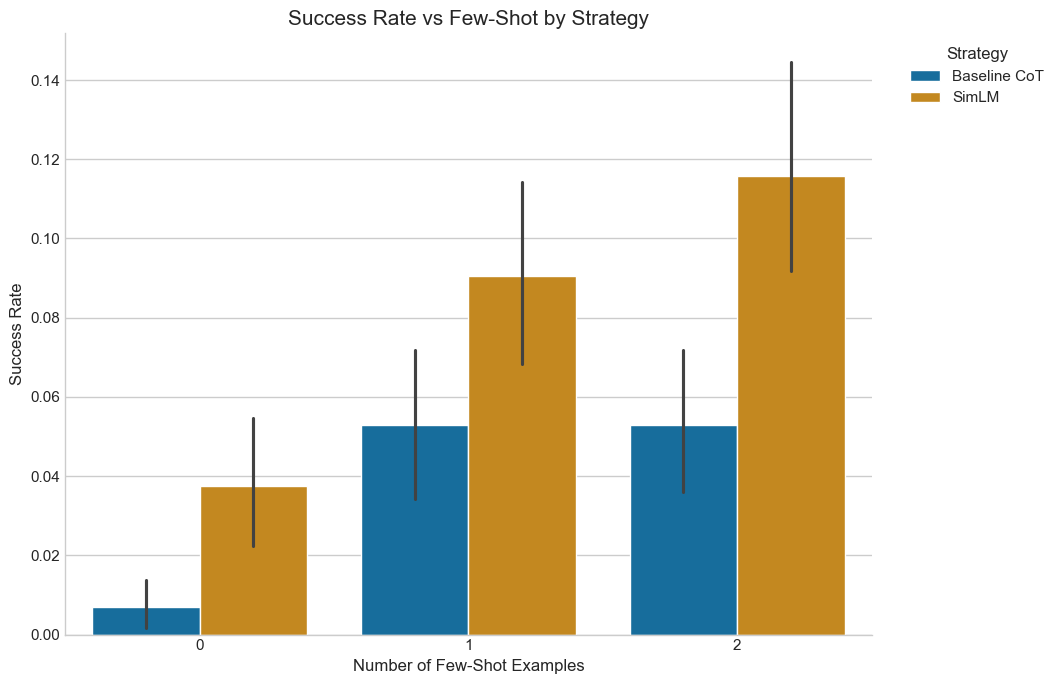

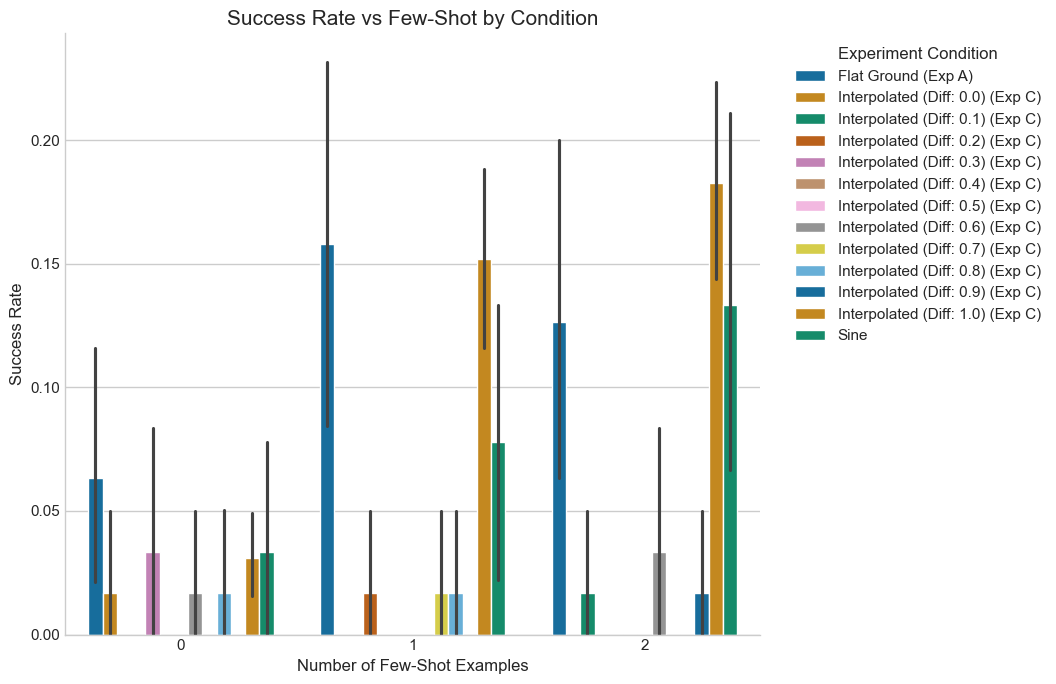


--- Analysis Complete ---


In [19]:
from simlm.analysis import summarize_fewshot_performance, plot_metric_by_fewshot_single_hist

summary_table = summarize_fewshot_performance(
            results_df, group_by_cols=['Experiment Condition', 'Strategy'])
print("\nSummary by Condition & Strategy:")
print(summary_table.to_string())

print("\n--- Generating Single Few-Shot Plots ---")
shots = sorted(results_df['Num Few Shot'].unique())
print(f"Analyzing few-shot counts found in data: {shots}")
# Plot Mean Error vs Few-Shot (Single Plot, Grouped by Condition)
plot_metric_by_fewshot_single_hist(
    results_df,
    metric='Error',
    title="Mean Error vs Few-Shot by Condition",
    shots_to_compare=shots,
    group_hue='Experiment Condition', # Conditions shown side-by-side
    x_group=None # Not grouping further on x for this plot
)

# Plot Success Rate vs Few-Shot (Single Plot, Grouped by Strategy)
plot_metric_by_fewshot_single_hist(
    results_df,
    metric='Success',
    title="Success Rate vs Few-Shot by Strategy",
    shots_to_compare=shots,
    group_hue='Strategy', # Strategies shown side-by-side
    x_group=None
)

    # Plot Success Rate vs Few-Shot (Single Plot, Grouped by Condition)
plot_metric_by_fewshot_single_hist(
    results_df,
    metric='Success',
    title="Success Rate vs Few-Shot by Condition",
    shots_to_compare=shots,
    group_hue='Experiment Condition', # Conditions shown side-by-side
    x_group=None
)

print("\n--- Analysis Complete ---")

